In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant

In [2]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

## Proportion recalled

In [3]:
n_episode_events = len(atlep1.events)
prop_rec_list = []
for rectype in ('atlep1', 'delayed'):
    for p in participants:
        matches = p.event_matches[rectype]
        prop_rec = len(np.unique(matches)) / n_episode_events
        prop_rec_list.append((f'P{p.sub_n}', rectype, prop_rec))
        
prop_recalled_df = pd.DataFrame(prop_rec_list, columns=('Participant', 'Session', 'Proportion recalled'))

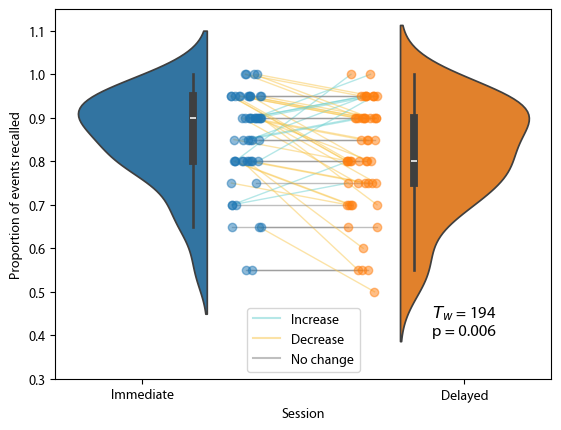

In [4]:
ax = sns.violinplot(prop_recalled_df, 
                    x='Session', 
                    y='Proportion recalled', 
                    hue='Session', split=True, gap=0.5)

inner_boxplot_xshift = 0.03
for line in ax.lines:
    xdata = line.get_xdata()
    center = np.mean(xdata)
    direction = -1 if center < 0.5 else 1  # left vs right violin
    line.set_xdata([x + direction * inner_boxplot_xshift for x in xdata])


imm_props = prop_recalled_df.query('Session == "atlep1"')['Proportion recalled']
del_props = prop_recalled_df.query('Session == "delayed"')['Proportion recalled']

imm_x_offset = 0.32
del_x_offset = -0.32
decrease_color = '#f9c74f'
increase_color = '#6cd0d0'
no_change_color = 'grey'

x_jitter = np.random.uniform(-0.05, 0.05, size=len(participants))

ax.scatter(np.zeros(len(imm_props)) + imm_x_offset + x_jitter, 
           imm_props, 
#            c=plt.cm.tab10(np.linspace(0, 1, len(imm_props), endpoint=True)), 
           color=plt.cm.tab10(0), 
           alpha=0.5,
           zorder=2)
ax.scatter(np.ones(len(del_props)) + del_x_offset + x_jitter, 
           del_props, 
#            c=plt.cm.tab10(np.linspace(0, 1, len(del_props), endpoint=True)), 
           color=plt.cm.tab10(1), 
           alpha=0.5,
           zorder=2)

ax.plot([np.zeros(len(imm_props)) + imm_x_offset + x_jitter, np.ones(len(del_props)) + del_x_offset + x_jitter], 
        [imm_props, del_props], 
        c=no_change_color, 
        alpha=0.5,
        lw=1,
        zorder=1)

for connection_line in ax.get_lines()[-len(participants):]:
    y_imm, y_del = connection_line.get_ydata()
    if y_imm > y_del:
        connection_line.set_color(decrease_color)
    elif y_imm < y_del:
        connection_line.set_color(increase_color)

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(('Immediate', 'Delayed'))
ax.set_ylabel('Proportion of events recalled')
ax.set_ylim(0.3, 1.15)

ax.legend((Line2D([0], [0], color=increase_color, alpha=0.5), 
           Line2D([0], [0], color=decrease_color, alpha=0.5), 
           Line2D([0], [0], color=no_change_color, alpha=0.5)), 
          ('Increase', 'Decrease', 'No change'), loc=8)

w, p = wilcoxon(imm_props, del_props)
ax.text(0.9, 0.4, f'$T_w$ = {w:.3g}\np = {p:.3f}', fontsize='large')

plt.show()

## Number of recall events

In [5]:
n_recall_events = {}
for rectype in ('atlep1', 'delayed'):
    n_ev = []
    for p in participants:
        n_ev.append(len(p.events[rectype]))
    n_recall_events[rectype] = n_ev
    
n_increases = sum(1 for i, j in zip(n_recall_events['atlep1'], n_recall_events['delayed']) if i < j)
n_decreases = sum(1 for i, j in zip(n_recall_events['atlep1'], n_recall_events['delayed']) if i > j)
n_no_change = len(participants) - n_increases - n_decreases

print(f'avg n immediate recall events: {np.mean(n_recall_events['atlep1'])}')
print(f'avg n delayed recall events: {np.mean(n_recall_events['delayed'])}')
print(f'number of increases: {n_increases}')
print(f'number of decreases: {n_decreases}')
print(f'number of no change: {n_no_change}')
print(wilcoxon(n_recall_events['atlep1'], n_recall_events['delayed']))

avg n immediate recall events: 18.245283018867923
avg n delayed recall events: 17.169811320754718
number of increases: 16
number of decreases: 33
number of no change: 4
WilcoxonResult(statistic=np.float64(321.5), pvalue=np.float64(0.003559012499377892))


## Serial position curve

In [6]:
spc_df = pd.DataFrame(columns=('Participant', 'Session', 'Event number', 'Recalled'))
row_ix = 0
for rectype in ('atlep1', 'delayed'):
    for p in participants:
        recalled_events = np.unique(p.event_matches[rectype])
        for episode_event_ix in range(len(atlep1.events)):
            spc_df.loc[row_ix] = (f'P{p.sub_n}', 
                                  rectype, 
                                  episode_event_ix, 
                                  int(episode_event_ix in recalled_events))
            row_ix += 1
            
spc_df['Session'] = spc_df['Session'].replace(
    {'atlep1': 'Immediate', 'delayed': 'Delayed'}
)

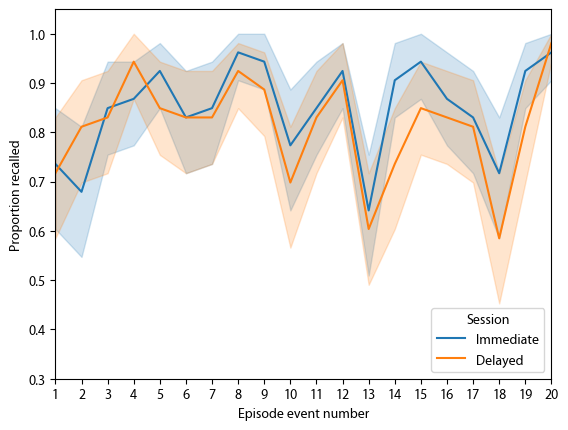

In [7]:
ax = sns.lineplot(spc_df, x='Event number', y='Recalled', hue='Session')
ax.set_xlim(0, len(atlep1.events) - 1)
ax.set_ylim(0.3, 1.05)
ax.set_xticks(list(range(len(atlep1.events))))
ax.set_xticklabels(list(range(1, len(atlep1.events) + 1)))
ax.set_xlabel('Episode event number')
ax.set_ylabel('Proportion recalled')
ax.get_legend().set_loc(4)
plt.show()

## Probability of first recall

In [8]:
pfr_df =  pd.DataFrame(columns=('Participant', 'Session', 'Event number', 'First recall'))
pfr_df[['Participant', 'Session', 'Event number']] = spc_df[['Participant', 'Session', 'Event number']]
pfr_df['First recall'] = 0

for rectype in ('atlep1', 'delayed'):
    ses_name = 'Immediate' if rectype == 'atlep1' else 'Delayed'
    for p in participants:
        first_rec = p.event_matches[rectype][0]
        pfr_df.loc[
            (pfr_df['Participant'] == f'P{p.sub_n}') & 
            (pfr_df['Session'] == ses_name) & 
            (pfr_df['Event number'] == first_rec), 
            'First recall'
        ] = 1

pfr_df['Session'] = pfr_df['Session'].replace(
    {'atlep1': 'Immediate', 'delayed': 'Delayed'}
)

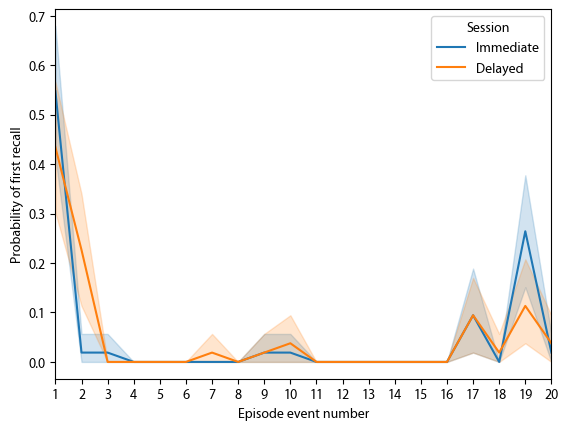

In [9]:
ax = sns.lineplot(pfr_df, x='Event number', y='First recall', hue='Session')
ax.set_xlim(0, len(atlep1.events) - 1)
# ax.set_ylim(0, 1)
ax.set_xticks(list(range(len(atlep1.events))))
ax.set_xticklabels(list(range(1, len(atlep1.events) + 1)))
ax.set_xlabel('Episode event number')
ax.set_ylabel('Probability of first recall')
plt.show()

## Lag-conditional response probability

In [10]:
def lagcrp_counts(recalls, n_items):
    """
    Accumulate actual and possible lag counts for one recall event sequence.
    """
    off = n_items - 1
    actual = np.zeros(2 * n_items - 1)
    possible = np.zeros(2 * n_items - 1)

    recalled = np.zeros(n_items, dtype=bool)
    recalled[recalls[0]] = True

    for k in range(1, len(recalls)):
        from_sp = recalls[k - 1]
        to_sp = recalls[k]

        # Only count a transition to an event not yet recalled.
        if not recalled[to_sp]:
            available = np.flatnonzero(~recalled)
            actual[to_sp - from_sp + off] += 1
            possible[available - from_sp + off] += 1

        recalled[to_sp] = True

    return actual, possible


n_episode_events = len(atlep1.events)
lags = np.arange(-n_episode_events + 1, n_episode_events)
n_lags = lags.shape[0]

lagcrp_df = pd.DataFrame(columns=('Participant', 'Session', 'lag', 'crp'),
                         index=range(len(participants) * 2 * len(lags)))
df_start_ix = 0

for rectype in ('atlep1', 'delayed'):
    for p in participants:
        recalled_events = np.asarray(p.event_matches[rectype])
        actual, possible = lagcrp_counts(recalled_events, n_episode_events)

        with np.errstate(divide='ignore', invalid='ignore'):
            crp = actual / possible
        crp[possible == 0] = np.nan

        lagcrp_df.loc[
            df_start_ix : df_start_ix + n_lags - 1,
            ('Participant', 'Session')
        ] = (f'P{p.sub_n}', rectype)
        lagcrp_df.loc[df_start_ix : df_start_ix + n_lags - 1, 'lag'] = lags
        lagcrp_df.loc[df_start_ix : df_start_ix + n_lags - 1, 'crp'] = crp
        
        df_start_ix += n_lags
        
lagcrp_df['Session'] = lagcrp_df['Session'].replace(
    {'atlep1': 'Immediate', 'delayed': 'Delayed'}
)

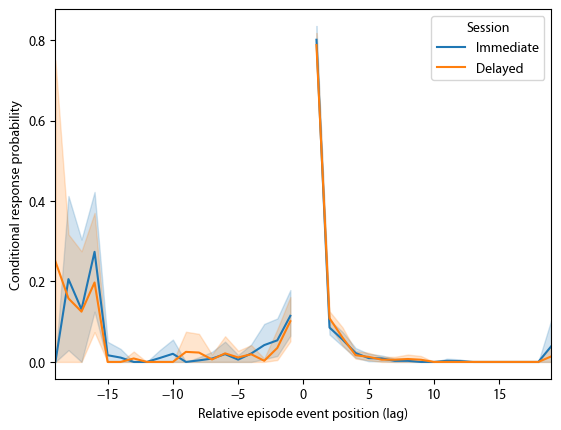

In [11]:
ax = sns.lineplot(lagcrp_df.loc[lagcrp_df['lag'] < 0], 
                  x='lag', 
                  y='crp', 
                  hue='Session')
sns.lineplot(lagcrp_df.loc[lagcrp_df['lag'] > 0], 
             x='lag', 
             y='crp',
             hue='Session', 
             legend=False,
             ax=ax)
ax.set_xlim(lags[0], lags[-1])
ax.set_xlabel('Relative episode event position (lag)')
ax.set_ylabel('Conditional response probability')
plt.show()

## Clustering

In [22]:
from scipy.spatial.distance import cdist

In [38]:
simmat = 1 - cdist(atlep1.events - atlep1.events.mean(0), atlep1.events - atlep1.events.mean(0), 'cosine')

lags_sims = []

for i in range(len(atlep1.events)):
    for j in range(i, len(atlep1.events)):
        lags_sims.append((j - i, simmat[i, j]))
    
df = pd.DataFrame(lags_sims, columns=('Lag', 'Similarity'))

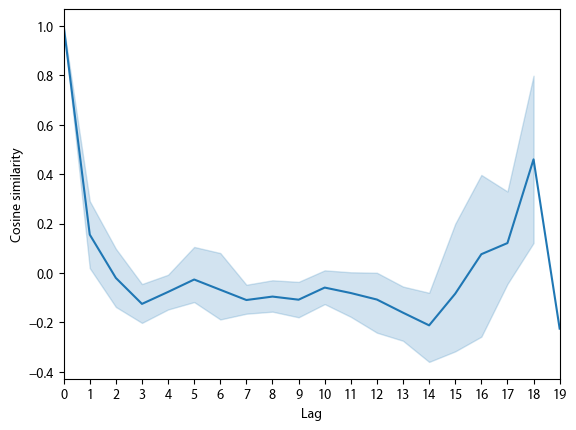

In [39]:
ax = sns.lineplot(df, x='Lag', y='Similarity')
ax.set_xlim(0, len(atlep1.events) - 1)
ax.set_xticks(list(range(len(atlep1.events))), labels=list(range(len(atlep1.events))))
ax.set_ylabel('Cosine similarity')
plt.show()

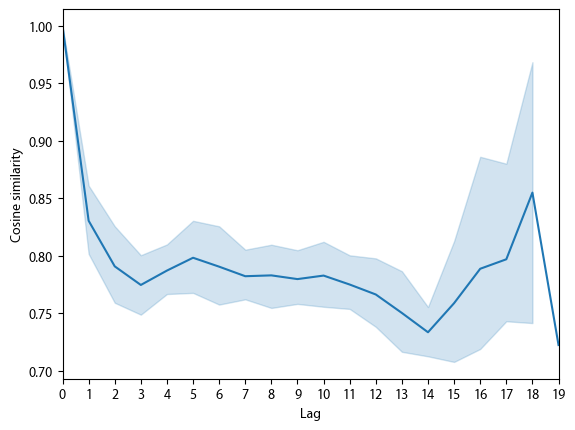

In [37]:
ax = sns.lineplot(df, x='Lag', y='Similarity')
ax.set_xlim(0, len(atlep1.events) - 1)
ax.set_xticks(list(range(len(atlep1.events))), labels=list(range(len(atlep1.events))))
ax.set_ylabel('Cosine similarity')
plt.show()

In [40]:
atlep1.events.shape

(20, 768)

In [44]:
df

,tid,pid,session,candidate,chosen,abs_lag,proximity,sim,sim_resid,prox_resid,proximity_z,sim_z,S,proxXS,simXS
0,0|atlep1|0,0,atlep1,1,1,1,-1.0,0.792098,-0.038470,5.909839,1.317104,0.091304,-0.5,-0.658552,-0.045652
1,0|atlep1|0,0,atlep1,2,0,2,-2.0,0.718474,-0.071022,6.009344,1.097304,-1.126359,-0.5,-0.548652,0.563179
2,0|atlep1|0,0,atlep1,3,0,3,-3.0,0.685294,-0.096256,5.504841,0.877504,-1.675103,-0.5,-0.438752,0.837552
3,0|atlep1|0,0,atlep1,4,0,4,-4.0,0.730345,-0.049668,3.832053,0.657704,-0.930014,-0.5,-0.328852,0.465007
4,0|atlep1|0,0,atlep1,5,0,5,-5.0,0.819014,0.039298,1.507887,0.437904,0.536452,-0.5,-0.218952,-0.268226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19046,52|delayed|8,52,delayed,11,0,5,-5.0,0.863183,0.083467,0.848269,0.437904,1.266956,0.5,0.218952,0.633478
19047,52|delayed|8,52,delayed,12,0,4,-4.0,0.829500,0.049487,2.351285,0.657704,0.709883,0.5,0.328852,0.354942
19048,52|delayed|8,52,delayed,17,0,1,-1.0,0.880579,0.050011,4.588477,1.317104,1.554666,0.5,0.658552,0.777333
19049,52|delayed|8,52,delayed,18,0,2,-2.0,0.958721,0.169225,2.421522,1.097304,2.847028,0.5,0.548652,1.423514


In [43]:
"""
Disentangling temporal vs. semantic clustering in naturalistic recall
=====================================================================

SKELETON / UNTESTED. Fill in the TODOs, sanity-check on your data, and treat
the modeling choices (decay form, repeat handling, bootstrap N) as knobs.

Pipeline
--------
Part 0  Quantify the temporal<->semantic confound in the stimulus.
Part 1  Build a per-(transition, candidate) table -- the shared substrate.
Part 2  GOAL 1: per-participant/session CORRECTED clustering scores
        (model-free residualized percentile ranks).
Part 3  GOAL 2: conditional-logit model + a contrast testing whether the
        temporal-vs-semantic emphasis shifts from immediate to delayed.
Part 4  Sanity check: simulate known strategies, confirm recovery.

Assumed in scope
----------------
atlep1.events                              -> ndarray (n_episode_events=20, 768)
participants                               -> list[Participant]
p.events["immediate"|"delayed"]            -> ndarray (n_recall_events, 768)
p.event_matches["immediate"|"delayed"]     -> ndarray (n_recall_events,) int,
                                              indices into atlep1.events
"""

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import percentileofscore, wilcoxon
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.discrete.conditional_models import ConditionalLogit

SESSIONS = ["atlep1", "delayed"]
RNG = np.random.default_rng(0)


# ============================================================================
# Part 0 -- Stimulus geometry: how conflated ARE temporal & semantic distance?
# ============================================================================
S = cosine_similarity(atlep1.events)                 # (20, 20) event-event sim
N_EV = S.shape[0]

iu, ju = np.triu_indices(N_EV, k=1)                  # unique unordered pairs
pair_lag = (ju - iu).astype(float)                   # |lag| for each pair
pair_sim = S[iu, ju]

# Smooth decay  sim ~ c + a * exp(-lag / tau).
# IMPORTANT: we deliberately fit a SMOOTH curve and let the lag-18 callback
# (events 1 & 19, the shooting shown twice) sit ABOVE it as a positive
# residual. That residual is genuine semantic structure -- it must NOT be
# absorbed into "expected similarity at this lag", or a 1->19 jump would be
# mislabeled as temporally ordinary. (This is also exactly why the joint
# model in Part 3 is the more trustworthy tool for this stimulus.)
def _decay(d, a, tau, c):
    return c + a * np.exp(-d / tau)

try:
    p0 = [pair_sim.max() - pair_sim.min(), 3.0, pair_sim.min()]
    decay_params, _ = curve_fit(_decay, pair_lag, pair_sim, p0=p0, maxfev=10000)
    def expected_sim(abs_lag):
        return _decay(np.asarray(abs_lag, float), *decay_params)
except Exception:
    # Fallback: robust per-lag median (still smooth-ish, less ideal).
    med = {d: np.median(pair_sim[pair_lag == d]) for d in np.unique(pair_lag)}
    def expected_sim(abs_lag):
        a = np.asarray(abs_lag, float)
        return np.vectorize(lambda d: med.get(d, np.median(pair_sim)))(a)

confound_r = np.corrcoef(-pair_lag, pair_sim)[0, 1]   # proximity vs similarity
print(f"[Part 0] proximity~similarity r = {confound_r:.3f}  "
      f"(closer to 0 => more separable; this stimulus has off-diagonal pairs)")


# ============================================================================
# Part 1 -- Per-(transition, candidate) table
# ============================================================================
# For each transition i -> i+1 we record EVERY not-yet-recalled candidate
# episode event, its features relative to the just-recalled event, and a
# 0/1 flag marking the one actually transitioned to (lag-CRP convention).

def build_rows(matches, pid, session, exclude_repeats=True):
    rows = []
    m = list(int(x) for x in matches)
    if len(m) < 2:
        return rows
    recalled = {m[0]}
    for t in range(len(m) - 1):
        j, nxt = m[t], m[t + 1]
        if exclude_repeats and nxt in recalled:
            # Many-to-one matching can produce repeats; standard CRP skips
            # transitions to already-recalled items. TODO: revisit if you
            # want to allow revisits instead.
            recalled.add(nxt)
            continue
        pool = [c for c in range(N_EV) if c not in recalled]  # excludes j too
        if nxt not in pool or len(pool) < 2:
            recalled.add(nxt)
            continue
        tid = f"{pid}|{session}|{t}"
        for c in pool:
            lag = abs(c - j)
            sim = float(S[j, c])
            rows.append(dict(
                tid=tid, pid=pid, session=session,
                candidate=c, chosen=int(c == nxt),
                abs_lag=lag,
                proximity=-float(lag),                       # higher = closer
                sim=sim,
                sim_resid=sim - float(expected_sim(lag)),    # semantic | temporal
            ))
        recalled.add(nxt)
    return rows

rows = []
for idx, p in enumerate(participants):
    pid = getattr(p, "id", idx)
    for s in SESSIONS:
        rows += build_rows(p.event_matches[s], pid, s)
df = pd.DataFrame(rows)

# Temporal-residualized-on-semantic feature (proximity | similarity), for the
# corrected TEMPORAL score. Linear fit on the candidate pairs is fine here.
g = np.polyfit(df["sim"], df["proximity"], deg=1)
df["prox_resid"] = df["proximity"] - np.polyval(g, df["sim"])


# ============================================================================
# Part 2 -- GOAL 1: corrected per-participant/session clustering scores
# ============================================================================
# Percentile rank (0..1) of the CHOSEN candidate's criterion value among the
# candidate pool, averaged over a cell's transitions. Swap the criterion to
# get raw vs. corrected, temporal vs. semantic.

def _trans_percentile(group, criterion):
    vals = group[criterion].values
    chosen = group.loc[group["chosen"] == 1, criterion].values[0]
    return percentileofscore(vals, chosen, kind="mean") / 100.0

def cell_scores(df):
    out = []
    for (pid, session), g_ in df.groupby(["pid", "session"]):
        trans = [t for _, t in g_.groupby("tid")]
        mean = lambda crit: float(np.mean([_trans_percentile(t, crit) for t in trans]))
        TCS = mean("prox_resid")   # temporal clustering, controlling for semantics
        SCS = mean("sim_resid")    # semantic clustering, controlling for temporal
        out.append(dict(
            pid=pid, session=session, n_trans=len(trans),
            TCS=TCS, SCS=SCS,
            TCS_raw=mean("proximity"), SCS_raw=mean("sim"),
            emphasis=TCS - SCS,    # >0 temporal-leaning, <0 semantic-leaning
        ))
    return pd.DataFrame(out)

scores = cell_scores(df)          # <-- GOAL 1 deliverable for downstream use
print("\n[Part 2] corrected per-cell scores (head):")
print(scores.head())


# ============================================================================
# Part 3 -- GOAL 2: does temporal-vs-semantic emphasis shift over the week?
# ============================================================================
# Conditional logit over each candidate set: P(choose c) ~ exp(b_T*prox +
# b_M*sim + b_TxS*prox*S + b_MxS*sim*S). Session effect-coded (-/+0.5), so:
#   b_T   = average temporal weight       b_TxS = temporal weight change (del-imm)
#   b_M   = average semantic weight       b_MxS = semantic weight change (del-imm)
# Predictors z-scored so b_T and b_M live on a common scale.
# Literature prediction: b_TxS < 0 and b_MxS > 0.
# Shift in RELATIVE emphasis = (b_TxS - b_MxS); that single contrast is GOAL 2.

for col in ["proximity", "sim"]:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()
df["S"] = df["session"].map({"atlep1": -0.5, "delayed": 0.5})
df["proxXS"] = df["proximity_z"] * df["S"]
df["simXS"]  = df["sim_z"] * df["S"]

FEATS = ["proximity_z", "sim_z", "proxXS", "simXS"]
NAMES = ["b_T", "b_M", "b_TxS", "b_MxS"]
L = np.array([0.0, 0.0, 1.0, -1.0])   # contrast: b_TxS - b_MxS

def fit_clogit(d):
    return ConditionalLogit(d["chosen"].values, d[FEATS].values,
                            groups=d["tid"].values).fit(disp=False)

res = fit_clogit(df)
print("\n[Part 3] conditional-logit coefficients:")
for nm, b in zip(NAMES, res.params):
    print(f"   {nm:6s} = {b:+.3f}")
contrast = float(L @ res.params)
print(f"   contrast (b_TxS - b_MxS) = {contrast:+.3f}  "
      f"(negative => emphasis shifts temporal->semantic with delay)")

# Participant-cluster bootstrap for a p-value that respects subject nesting.
pids = scores["pid"].unique()
boot = []
for _ in range(2000):                          # TODO: bump for final results
    samp = RNG.choice(pids, size=len(pids), replace=True)
    parts = []
    for k, pp in enumerate(samp):
        sub = df[df["pid"] == pp].copy()
        sub["tid"] = sub["tid"] + f"#{k}"       # keep groups unique per draw
        parts.append(sub)
    d = pd.concat(parts, ignore_index=True)
    try:
        boot.append(float(L @ fit_clogit(d).params))
    except Exception:
        pass
boot = np.array(boot)
ci = np.percentile(boot, [2.5, 97.5])
p_boot = 2 * min((boot <= 0).mean(), (boot >= 0).mean())
print(f"   bootstrap 95% CI = [{ci[0]:+.3f}, {ci[1]:+.3f}]  p = {p_boot:.4f}")

# Simpler, assumption-light cross-check on the GOAL-1 scores: paired test on
# the emphasis index, plus the two directional predictions separately.
def paired(col):
    w = scores.pivot(index="pid", columns="session", values=col)
    stat, pval = wilcoxon(w["delayed"], w["atlep1"])
    return float((w["delayed"] - w["atlep1"]).mean()), pval

for col in ["emphasis", "TCS", "SCS"]:
    d_mean, pval = paired(col)
    print(f"[Part 3] paired {col:8s} delayed-immediate = {d_mean:+.3f}  p = {pval:.4f}")


# ============================================================================
# Part 4 -- Sanity check: can the metrics recover KNOWN strategies?
# ============================================================================
# Simulate recall over the ACTUAL episode structure under a pure-temporal and
# a pure-semantic walker; run them through Parts 1-2; confirm a temporal walker
# scores high TCS / chance SCS and vice versa. If a pure-temporal walker also
# scores high corrected SCS, this stimulus genuinely can't separate the two.

def simulate(weights, n_steps=12, n_runs=50):
    """weights = (wT, wM). Returns list of synthetic match-index sequences."""
    wT, wM = weights
    proxz = (-np.arange(N_EV)[:, None] + np.arange(N_EV)[None, :])  # placeholder
    seqs = []
    for _ in range(n_runs):
        recalled, seq = set(), []
        cur = int(RNG.integers(N_EV))
        seq.append(cur); recalled.add(cur)
        for _ in range(n_steps - 1):
            pool = [c for c in range(N_EV) if c not in recalled]
            if not pool:
                break
            prox = -np.abs(np.array(pool) - cur)
            sim = S[cur, pool]
            z = lambda v: (v - v.mean()) / (v.std() + 1e-9)
            logits = wT * z(prox) + wM * z(sim)
            probs = np.exp(logits - logits.max()); probs /= probs.sum()
            cur = int(RNG.choice(pool, p=probs))
            seq.append(cur); recalled.add(cur)
        seqs.append(np.array(seq))
    return seqs

for label, w in [("pure-temporal", (3.0, 0.0)), ("pure-semantic", (0.0, 3.0))]:
    sim_rows = []
    for r, seq in enumerate(simulate(w)):
        sim_rows += build_rows(seq, f"sim{r}", "atlep1")
    sdf = pd.DataFrame(sim_rows)
    g2 = np.polyfit(sdf["sim"], sdf["proximity"], 1)
    sdf["prox_resid"] = sdf["proximity"] - np.polyval(g2, sdf["sim"])
    ss = cell_scores(sdf)
    print(f"[Part 4] {label:14s} -> corrected TCS={ss['TCS'].mean():.2f}  "
          f"SCS={ss['SCS'].mean():.2f}")

[Part 0] proximity~similarity r = 0.196  (closer to 0 => more separable; this stimulus has off-diagonal pairs)

[Part 2] corrected per-cell scores (head):
   pid  session  n_trans       TCS       SCS   TCS_raw   SCS_raw  emphasis
0    0   atlep1       18  0.797138  0.513382  0.834678  0.619217  0.283757
1    0  delayed       17  0.820344  0.571259  0.918428  0.682881  0.249086
2    1   atlep1       12  0.796650  0.531129  0.857982  0.634831  0.265521
3    1  delayed       12  0.742143  0.584334  0.805215  0.708074  0.157809
4    2   atlep1       18  0.807388  0.537449  0.929229  0.686382  0.269939

[Part 3] conditional-logit coefficients:
   b_T    = +3.476
   b_M    = +0.332
   b_TxS  = +0.381
   b_MxS  = -0.096
   contrast (b_TxS - b_MxS) = +0.477  (negative => emphasis shifts temporal->semantic with delay)
   bootstrap 95% CI = [-0.251, +1.174]  p = 0.1940
[Part 3] paired emphasis delayed-immediate = +0.032  p = 0.0183
[Part 3] paired TCS      delayed-immediate = +0.013  p = 0.0594


# mean-centered version

In [49]:
from tqdm.notebook import tqdm

In [52]:
"""
Disentangling temporal vs. semantic clustering in naturalistic recall
=====================================================================

SKELETON / UNTESTED. Fill in the TODOs, sanity-check on your data, and treat
the modeling choices (decay form, repeat handling, bootstrap N) as knobs.

Pipeline
--------
Part 0  Quantify the temporal<->semantic confound in the stimulus.
Part 1  Build a per-(transition, candidate) table -- the shared substrate.
Part 2  GOAL 1: per-participant/session CORRECTED clustering scores
        (model-free residualized percentile ranks).
Part 3  GOAL 2: conditional-logit model + a contrast testing whether the
        temporal-vs-semantic emphasis shifts from immediate to delayed.
Part 4  Sanity check: simulate known strategies, confirm recovery.

Assumed in scope
----------------
atlep1.events                              -> ndarray (n_episode_events=20, 768)
participants                               -> list[Participant]
p.events["immediate"|"delayed"]            -> ndarray (n_recall_events, 768)
p.event_matches["immediate"|"delayed"]     -> ndarray (n_recall_events,) int,
                                              indices into atlep1.events
"""

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import percentileofscore, wilcoxon
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.discrete.conditional_models import ConditionalLogit

SESSIONS = ["atlep1", "delayed"]
RNG = np.random.default_rng(0)


# ============================================================================
# Part 0 -- Stimulus geometry: how conflated ARE temporal & semantic distance?
# ============================================================================
S = cosine_similarity(atlep1.events - atlep1.events.mean(axis=0))                 # (20, 20) event-event sim
N_EV = S.shape[0]

iu, ju = np.triu_indices(N_EV, k=1)                  # unique unordered pairs
pair_lag = (ju - iu).astype(float)                   # |lag| for each pair
pair_sim = S[iu, ju]

# Smooth decay  sim ~ c + a * exp(-lag / tau).
# IMPORTANT: we deliberately fit a SMOOTH curve and let the lag-18 callback
# (events 1 & 19, the shooting shown twice) sit ABOVE it as a positive
# residual. That residual is genuine semantic structure -- it must NOT be
# absorbed into "expected similarity at this lag", or a 1->19 jump would be
# mislabeled as temporally ordinary. (This is also exactly why the joint
# model in Part 3 is the more trustworthy tool for this stimulus.)
def _decay(d, a, tau, c):
    return c + a * np.exp(-d / tau)

try:
    p0 = [pair_sim.max() - pair_sim.min(), 3.0, pair_sim.min()]
    decay_params, _ = curve_fit(_decay, pair_lag, pair_sim, p0=p0, maxfev=10000)
    def expected_sim(abs_lag):
        return _decay(np.asarray(abs_lag, float), *decay_params)
except Exception:
    # Fallback: robust per-lag median (still smooth-ish, less ideal).
    med = {d: np.median(pair_sim[pair_lag == d]) for d in np.unique(pair_lag)}
    def expected_sim(abs_lag):
        a = np.asarray(abs_lag, float)
        return np.vectorize(lambda d: med.get(d, np.median(pair_sim)))(a)

confound_r = np.corrcoef(-pair_lag, pair_sim)[0, 1]   # proximity vs similarity
print(f"[Part 0] proximity~similarity r = {confound_r:.3f}  "
      f"(closer to 0 => more separable; this stimulus has off-diagonal pairs)")


# ============================================================================
# Part 1 -- Per-(transition, candidate) table
# ============================================================================
# For each transition i -> i+1 we record EVERY not-yet-recalled candidate
# episode event, its features relative to the just-recalled event, and a
# 0/1 flag marking the one actually transitioned to (lag-CRP convention).

def build_rows(matches, pid, session, exclude_repeats=True):
    rows = []
    m = list(int(x) for x in matches)
    if len(m) < 2:
        return rows
    recalled = {m[0]}
    for t in range(len(m) - 1):
        j, nxt = m[t], m[t + 1]
        if exclude_repeats and nxt in recalled:
            # Many-to-one matching can produce repeats; standard CRP skips
            # transitions to already-recalled items. TODO: revisit if you
            # want to allow revisits instead.
            recalled.add(nxt)
            continue
        pool = [c for c in range(N_EV) if c not in recalled]  # excludes j too
        if nxt not in pool or len(pool) < 2:
            recalled.add(nxt)
            continue
        tid = f"{pid}|{session}|{t}"
        for c in pool:
            lag = abs(c - j)
            sim = float(S[j, c])
            rows.append(dict(
                tid=tid, pid=pid, session=session,
                candidate=c, chosen=int(c == nxt),
                abs_lag=lag,
                proximity=-float(lag),                       # higher = closer
                sim=sim,
                sim_resid=sim - float(expected_sim(lag)),    # semantic | temporal
            ))
        recalled.add(nxt)
    return rows

rows = []
for idx, p in enumerate(participants):
    pid = getattr(p, "id", idx)
    for s in SESSIONS:
        rows += build_rows(p.event_matches[s], pid, s)
df = pd.DataFrame(rows)

# Temporal-residualized-on-semantic feature (proximity | similarity), for the
# corrected TEMPORAL score. Linear fit on the candidate pairs is fine here.
g = np.polyfit(df["sim"], df["proximity"], deg=1)
df["prox_resid"] = df["proximity"] - np.polyval(g, df["sim"])


# ============================================================================
# Part 2 -- GOAL 1: corrected per-participant/session clustering scores
# ============================================================================
# Percentile rank (0..1) of the CHOSEN candidate's criterion value among the
# candidate pool, averaged over a cell's transitions. Swap the criterion to
# get raw vs. corrected, temporal vs. semantic.

def _trans_percentile(group, criterion):
    vals = group[criterion].values
    chosen = group.loc[group["chosen"] == 1, criterion].values[0]
    return percentileofscore(vals, chosen, kind="mean") / 100.0

def cell_scores(df):
    out = []
    for (pid, session), g_ in df.groupby(["pid", "session"]):
        trans = [t for _, t in g_.groupby("tid")]
        mean = lambda crit: float(np.mean([_trans_percentile(t, crit) for t in trans]))
        TCS = mean("prox_resid")   # temporal clustering, controlling for semantics
        SCS = mean("sim_resid")    # semantic clustering, controlling for temporal
        out.append(dict(
            pid=pid, session=session, n_trans=len(trans),
            TCS=TCS, SCS=SCS,
            TCS_raw=mean("proximity"), SCS_raw=mean("sim"),
            emphasis=TCS - SCS,    # >0 temporal-leaning, <0 semantic-leaning
        ))
    return pd.DataFrame(out)

scores = cell_scores(df)          # <-- GOAL 1 deliverable for downstream use
print("\n[Part 2] corrected per-cell scores (head):")
print(scores.head())


# ============================================================================
# Part 3 -- GOAL 2: does temporal-vs-semantic emphasis shift over the week?
# ============================================================================
# Conditional logit over each candidate set: P(choose c) ~ exp(b_T*prox +
# b_M*sim + b_TxS*prox*S + b_MxS*sim*S). Session effect-coded (-/+0.5), so:
#   b_T   = average temporal weight       b_TxS = temporal weight change (del-imm)
#   b_M   = average semantic weight       b_MxS = semantic weight change (del-imm)
# Predictors z-scored so b_T and b_M live on a common scale.
# Literature prediction: b_TxS < 0 and b_MxS > 0.
# Shift in RELATIVE emphasis = (b_TxS - b_MxS); that single contrast is GOAL 2.

for col in ["proximity", "sim"]:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()
df["S"] = df["session"].map({"atlep1": -0.5, "delayed": 0.5})
df["proxXS"] = df["proximity_z"] * df["S"]
df["simXS"]  = df["sim_z"] * df["S"]

FEATS = ["proximity_z", "sim_z", "proxXS", "simXS"]
NAMES = ["b_T", "b_M", "b_TxS", "b_MxS"]
L = np.array([0.0, 0.0, 1.0, -1.0])   # contrast: b_TxS - b_MxS

def fit_clogit(d):
    return ConditionalLogit(d["chosen"].values, d[FEATS].values,
                            groups=d["tid"].values).fit(disp=False)

res = fit_clogit(df)
print("\n[Part 3] conditional-logit coefficients:")
for nm, b in zip(NAMES, res.params):
    print(f"   {nm:6s} = {b:+.3f}")
contrast = float(L @ res.params)
print(f"   contrast (b_TxS - b_MxS) = {contrast:+.3f}  "
      f"(negative => emphasis shifts temporal->semantic with delay)")

# Participant-cluster bootstrap for a p-value that respects subject nesting.
pids = scores["pid"].unique()
boot = []
for _ in tqdm(range(1000)):                          # TODO: bump for final results
    samp = RNG.choice(pids, size=len(pids), replace=True)
    parts = []
    for k, pp in enumerate(samp):
        sub = df[df["pid"] == pp].copy()
        sub["tid"] = sub["tid"] + f"#{k}"       # keep groups unique per draw
        parts.append(sub)
    d = pd.concat(parts, ignore_index=True)
    try:
        boot.append(float(L @ fit_clogit(d).params))
    except Exception:
        pass
boot = np.array(boot)
ci = np.percentile(boot, [2.5, 97.5])
p_boot = 2 * min((boot <= 0).mean(), (boot >= 0).mean())
print(f"   bootstrap 95% CI = [{ci[0]:+.3f}, {ci[1]:+.3f}]  p = {p_boot:.4f}")

# Simpler, assumption-light cross-check on the GOAL-1 scores: paired test on
# the emphasis index, plus the two directional predictions separately.
def paired(col):
    w = scores.pivot(index="pid", columns="session", values=col)
    stat, pval = wilcoxon(w["delayed"], w["atlep1"])
    return float((w["delayed"] - w["atlep1"]).mean()), pval

for col in ["emphasis", "TCS", "SCS"]:
    d_mean, pval = paired(col)
    print(f"[Part 3] paired {col:8s} delayed-immediate = {d_mean:+.3f}  p = {pval:.4f}")


# ============================================================================
# Part 4 -- Sanity check: can the metrics recover KNOWN strategies?
# ============================================================================
# Simulate recall over the ACTUAL episode structure under a pure-temporal and
# a pure-semantic walker; run them through Parts 1-2; confirm a temporal walker
# scores high TCS / chance SCS and vice versa. If a pure-temporal walker also
# scores high corrected SCS, this stimulus genuinely can't separate the two.

# def simulate(weights, n_steps=12, n_runs=50):
#     """weights = (wT, wM). Returns list of synthetic match-index sequences."""
#     wT, wM = weights
#     proxz = (-np.arange(N_EV)[:, None] + np.arange(N_EV)[None, :])  # placeholder
#     seqs = []
#     for _ in range(n_runs):
#         recalled, seq = set(), []
#         cur = int(RNG.integers(N_EV))
#         seq.append(cur); recalled.add(cur)
#         for _ in range(n_steps - 1):
#             pool = [c for c in range(N_EV) if c not in recalled]
#             if not pool:
#                 break
#             prox = -np.abs(np.array(pool) - cur)
#             sim = S[cur, pool]
#             z = lambda v: (v - v.mean()) / (v.std() + 1e-9)
#             logits = wT * z(prox) + wM * z(sim)
#             probs = np.exp(logits - logits.max()); probs /= probs.sum()
#             cur = int(RNG.choice(pool, p=probs))
#             seq.append(cur); recalled.add(cur)
#         seqs.append(np.array(seq))
#     return seqs

# for label, w in [("pure-temporal", (3.0, 0.0)), ("pure-semantic", (0.0, 3.0))]:
#     sim_rows = []
#     for r, seq in enumerate(simulate(w)):
#         sim_rows += build_rows(seq, f"sim{r}", "atlep1")
#     sdf = pd.DataFrame(sim_rows)
#     g2 = np.polyfit(sdf["sim"], sdf["proximity"], 1)
#     sdf["prox_resid"] = sdf["proximity"] - np.polyval(g2, sdf["sim"])
#     ss = cell_scores(sdf)
#     print(f"[Part 4] {label:14s} -> corrected TCS={ss['TCS'].mean():.2f}  "
#           f"SCS={ss['SCS'].mean():.2f}")

[Part 0] proximity~similarity r = 0.097  (closer to 0 => more separable; this stimulus has off-diagonal pairs)

[Part 2] corrected per-cell scores (head):
   pid  session  n_trans       TCS       SCS   TCS_raw   SCS_raw  emphasis
0    0   atlep1       18  0.801122  0.562262  0.834678  0.660372  0.238861
1    0  delayed       17  0.874032  0.555961  0.918428  0.671295  0.318070
2    1   atlep1       12  0.846187  0.441119  0.857982  0.560461  0.405068
3    1  delayed       12  0.769812  0.549444  0.805215  0.663291  0.220368
4    2   atlep1       18  0.880817  0.519028  0.929229  0.658805  0.361789

[Part 3] conditional-logit coefficients:
   b_T    = +3.387
   b_M    = +0.326
   b_TxS  = +0.372
   b_MxS  = -0.067
   contrast (b_TxS - b_MxS) = +0.439  (negative => emphasis shifts temporal->semantic with delay)


  0%|          | 0/1000 [00:00<?, ?it/s]

   bootstrap 95% CI = [-0.314, +1.142]  p = 0.2380
[Part 3] paired emphasis delayed-immediate = +0.019  p = 0.2293
[Part 3] paired TCS      delayed-immediate = +0.008  p = 0.6819
[Part 3] paired SCS      delayed-immediate = -0.011  p = 0.2665
